# Participant Demographics EDA (Step01 Baseline)

Dataset:
- `data/stepwise_cleaned_versions/01_participant_level_checks/participant_level_checks__step01_drop_items_and_flagged_participants/ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv`

Goals:
1. Report collection date range (`submitted`, date only)
2. Analyze age distribution with annotated plot
3. Plot gender (`M` / `F`) proportions
4. Plot `humanities or not` (`+` / `-`) proportions
5. Audit and harmonize `education and profession` categories before calculating percentages

### Plot design notes

This notebook follows simple publication-focused rules:
- Use color only when it adds information (avoid decorative color overload)
- Keep y-axis starting at zero for bar charts
- Use clear labels, readable annotations, and minimal clutter
- Prefer one neutral palette with selective highlights for key values

In [58]:
from pathlib import Path
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

In [59]:
# Frozen color constants for visual consistency across all notebook plots
# These hex values were generated once from:
# load_cmap(["Joyful", "Juarez", "Kandinsky"]) and then fixed.
CATEGORY_COLOR_MAP = {
    "Science and Education": "#c94277",
    "Service Industry": "#274c77",
    "IT and Engineering": "#208cc0",
    "Art and Culture": "#cf5e4e",
    "Student/School": "#3b7c70",
    "Missing/Unknown": "#898e9f",
}

SEX_COLOR_MAP = {
    "Female": CATEGORY_COLOR_MAP["Art and Culture"],
    "Male": CATEGORY_COLOR_MAP["IT and Engineering"],
    "Missing/Other": CATEGORY_COLOR_MAP["Missing/Unknown"],
}

HUM_COLOR_MAP = {
    "Humanities: Yes": CATEGORY_COLOR_MAP["Science and Education"],
    "Humanities: No": CATEGORY_COLOR_MAP["Service Industry"],
    "Missing/Other": CATEGORY_COLOR_MAP["Missing/Unknown"],
}

AGE_COLOR_MAP = {
    "tail": CATEGORY_COLOR_MAP["Missing/Unknown"],
    "mid": CATEGORY_COLOR_MAP["IT and Engineering"],
    "center": CATEGORY_COLOR_MAP["Service Industry"],
    "curve": CATEGORY_COLOR_MAP["Art and Culture"],
    "mean": CATEGORY_COLOR_MAP["Science and Education"],
    "median": CATEGORY_COLOR_MAP["Student/School"],
}

In [60]:
# Load step01 baseline and locate required demographic columns
PROJECT_ROOT = Path("..").resolve().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "stepwise_cleaned_versions"
    / "01_participant_level_checks"
    / "participant_level_checks__step01_drop_items_and_flagged_participants"
    / "ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv"
)

raw = pd.read_csv(DATA_PATH, header=None)
labels = raw.iloc[0].fillna("").astype(str).tolist()
responses = raw.iloc[2:, :].reset_index(drop=True)


def norm_label(s: str) -> str:
    return " ".join(str(s).strip().lower().split())


label_to_idx = {norm_label(lbl): idx for idx, lbl in enumerate(labels)}


def find_col(possible_names):
    for name in possible_names:
        key = norm_label(name)
        if key in label_to_idx:
            return label_to_idx[key]
    return None


col_submitted = find_col(["submitted", "submited"])
col_age = find_col(["age"])
col_sex = find_col(["sex", "sex "])
col_hum = find_col(["humanities or not"])
col_edu = find_col(["education and profession"])

required = {
    "submitted": col_submitted,
    "age": col_age,
    "sex": col_sex,
    "humanities_or_not": col_hum,
    "education_and_profession": col_edu,
}

missing_cols = [k for k, v in required.items() if v is None]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

demo = pd.DataFrame(
    {
        "submitted": responses.iloc[:, col_submitted],
        "age": responses.iloc[:, col_age],
        "sex": responses.iloc[:, col_sex],
        "humanities_or_not": responses.iloc[:, col_hum],
        "education_and_profession": responses.iloc[:, col_edu],
    }
).copy()

print(f"Loaded: {DATA_PATH}")
print(f"Rows (participants): {len(demo)}")
display(demo.head(5))

Loaded: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/01_participant_level_checks/participant_level_checks__step01_drop_items_and_flagged_participants/ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv
Rows (participants): 1010


,submitted,age,sex,humanities_or_not,education_and_profession
0,02/05/2020 12:37,20.0,M,-,IT and engineering
1,02/05/2020 11:58,50.0,F,-,service industry
2,02/05/2020 11:40,23.0,F,-,service industry
3,02/05/2020 11:21,27.0,F,-,science and education
4,02/05/2020 10:53,15.0,F,NaN,NaN


In [61]:
# Submitted date range (date only, time removed)
submitted_dt = pd.to_datetime(demo["submitted"], errors="coerce")
submitted_date = submitted_dt.dt.date

n_missing_dates = submitted_dt.isna().sum()
min_date = submitted_date.min()
max_date = submitted_date.max()

print("Collection date range (date only):")
print(f"- Start date: {min_date}")
print(f"- End date:   {max_date}")
print(f"- Missing/unparseable submitted timestamps: {n_missing_dates}")

Collection date range (date only):
- Start date: 2020-01-14
- End date:   2020-02-05
- Missing/unparseable submitted timestamps: 0


In [62]:
# Age: cleaning and descriptive stats
age_num = pd.to_numeric(demo["age"], errors="coerce")

# Keep plausible participant ages; report anything outside this range.
age_valid = age_num[(age_num >= 10) & (age_num <= 100)]
age_invalid_count = age_num.notna().sum() - age_valid.shape[0]
age_missing_count = age_num.isna().sum()

age_invalid_values = age_num[(age_num.notna()) & ~((age_num >= 10) & (age_num <= 100))]
age_under_18 = age_valid[age_valid < 18]

print("Age quality check")
print(f"- Valid ages (10-100): {len(age_valid)}")
print(f"- Missing ages: {age_missing_count}")
print(f"- Invalid numeric ages outside 10-100: {age_invalid_count}")
if len(age_invalid_values) > 0:
    inv_vc = age_invalid_values.value_counts().sort_index()
    inv_str = ", ".join(f"{int(v)}(×{c})" for v, c in inv_vc.items())
    print(f"  → Invalid age values: {inv_str}")

print(f"\n- Participants under 18 (within valid range): {len(age_under_18)}")
if len(age_under_18) > 0:
    u18_vc = age_under_18.value_counts().sort_index()
    u18_str = ", ".join(f"age {int(a)}: n={c}" for a, c in u18_vc.items())
    print(f"  → Breakdown: {u18_str}")
print("  ⚠ NOTE: participants younger than 18 will need to be excluded in a later step.")

print("\nAge descriptive statistics (valid ages)")
print(age_valid.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

Age quality check
- Valid ages (10-100): 1001
- Missing ages: 0
- Invalid numeric ages outside 10-100: 9
  → Invalid age values: 1(×9)

- Participants under 18 (within valid range): 93
  → Breakdown: age 12: n=1, age 13: n=3, age 14: n=9, age 15: n=15, age 16: n=18, age 17: n=47
  ⚠ NOTE: participants younger than 18 will need to be excluded in a later step.

Age descriptive statistics (valid ages)
count    1001.000000
mean       27.887113
std         9.345600
min        12.000000
5%         17.000000
25%        21.000000
50%        27.000000
75%        32.000000
95%        46.000000
max        65.000000


In [63]:
# Step02/03 age-based exports and adults-only analysis frame
# Step02: keep only valid under-18 participants (for audit)
# Step03: keep only valid adults (18+) for downstream demographics analysis
age_valid_mask = (age_num >= 10) & (age_num <= 100)
age_invalid_numeric_mask = age_num.notna() & ~age_valid_mask
age_under_18_mask = age_valid_mask & (age_num < 18)
age_adult_mask = age_valid_mask & (age_num >= 18)

stepwise_root = PROJECT_ROOT / "data" / "stepwise_cleaned_versions" / "02_participant_demographics"

under18_dir = stepwise_root / "participant_demographics__step02_under18_only"
adults_dir = stepwise_root / "participant_demographics__step03_valid_age_adults_only"
under18_dir.mkdir(parents=True, exist_ok=True)
adults_dir.mkdir(parents=True, exist_ok=True)

under18_path = (
    under18_dir
    / "ART_pretest_(for Castano)_EN__participant_demographics_step02_under18_only.csv"
)
adults_path = (
    adults_dir
    / "ART_pretest_(for Castano)_EN__participant_demographics_step03_valid_age_adults_only.csv"
)

# Save full-width step files (same structure as step01):
# row 0 = labels, row 1 = marker codes (cla/mod/fill/etc.), rows 2+ = participants.
header_rows = raw.iloc[:2, :].copy()
responses_under18_full = responses.loc[age_under_18_mask.values, :].copy().reset_index(drop=True)
responses_adults_full = responses.loc[age_adult_mask.values, :].copy().reset_index(drop=True)

out_under18_full = pd.concat([header_rows, responses_under18_full], ignore_index=True)
out_adults_full = pd.concat([header_rows, responses_adults_full], ignore_index=True)
out_under18_full.to_csv(under18_path, index=False, header=False)
out_adults_full.to_csv(adults_path, index=False, header=False)

# Keep compact demographic frames for downstream EDA calculations.
demo_under18 = demo.loc[age_under_18_mask].copy()
demo_adults = demo.loc[age_adult_mask].copy()

print("Age-based export summary")
print(f"- Rows with invalid numeric ages (excluded): {int(age_invalid_numeric_mask.sum())}")
print(f"- Under-18 rows exported: {len(demo_under18)}")
print(f"- Adults-only rows exported: {len(demo_adults)}")
print(f"- Saved under-18 audit CSV (full width): {under18_path}")
print(f"- Saved adults-only analysis CSV (full width): {adults_path}")

# Rebind active analysis frame to adults only so subsequent cells recompute on adults.
demo = demo_adults.copy()
age_valid = age_num.loc[age_adult_mask].copy()
age_under_18 = age_num.loc[age_under_18_mask].copy()

print("\nActive analysis frame switched to adults-only data.")
print(f"- demo rows now used downstream: {len(demo)}")

Age-based export summary
- Rows with invalid numeric ages (excluded): 9
- Under-18 rows exported: 93
- Adults-only rows exported: 908
- Saved under-18 audit CSV (full width): /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/02_participant_demographics/participant_demographics__step02_under18_only/ART_pretest_(for Castano)_EN__participant_demographics_step02_under18_only.csv
- Saved adults-only analysis CSV (full width): /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/02_participant_demographics/participant_demographics__step03_valid_age_adults_only/ART_pretest_(for Castano)_EN__participant_demographics_step03_valid_age_adults_only.csv

Active analysis frame switched to adults-only data.
- demo rows now used downstream: 908



Adult age summary statistics
count    908.000000
mean      29.103524
std        8.955253
min       18.000000
5%        18.000000
25%       22.000000
50%       27.000000
75%       33.000000
95%       46.650000
max       65.000000


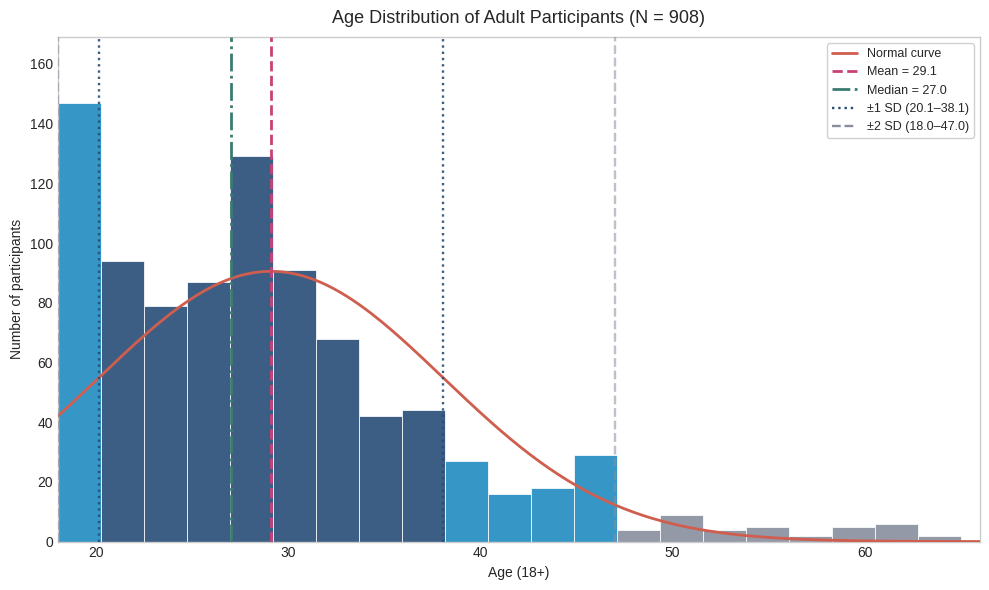

In [64]:
# Age distribution plot (publication-ready with annotations)
# Bin strategy: Freedman-Diaconis adapts to data spread and sample size,
# generally producing more informative bins than Sturges for skewed data.
# See reference style patterns: https://python-graph-gallery.com/histogram/
fig, ax = plt.subplots(figsize=(10, 6))

adult_age = age_valid[age_valid >= 18].dropna()

mean_age = adult_age.mean()
median_age = adult_age.median()
std_age = adult_age.std()

bins_fd = np.histogram_bin_edges(adult_age, bins="fd")
my_hist, bin_edges = np.histogram(adult_age, bins=bins_fd)

sd1_low = max(18.0, mean_age - std_age)
sd1_high = mean_age + std_age
sd2_low = max(18.0, mean_age - 2 * std_age)
sd2_high = mean_age + 2 * std_age
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
tail_color = AGE_COLOR_MAP["tail"]
mid_color = AGE_COLOR_MAP["mid"]
center_color = AGE_COLOR_MAP["center"]
colors = [
    tail_color
    if (center < sd2_low or center > sd2_high)
    else (mid_color if (center < sd1_low or center > sd1_high) else center_color)
    for center in bin_centers
]

# Draw histogram using bar() for fine-grained styling control.
ax.bar(
    bin_edges[:-1],
    my_hist,
    width=np.diff(bin_edges),
    align="edge",
    color=colors,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9,
    zorder=2,
)

x_curve = np.linspace(adult_age.min() - 1, adult_age.max() + 1, 300)
bin_width = bin_edges[1] - bin_edges[0]
y_curve = stats.norm.pdf(x_curve, mean_age, std_age) * len(adult_age) * bin_width
ax.plot(x_curve, y_curve, color=AGE_COLOR_MAP["curve"], linewidth=2, label="Normal curve", zorder=3)

ax.axvline(mean_age, color=AGE_COLOR_MAP["mean"], linestyle="--", linewidth=2,
           label=f"Mean = {mean_age:.1f}", zorder=4)
ax.axvline(median_age, color=AGE_COLOR_MAP["median"], linestyle="-.", linewidth=2,
           label=f"Median = {median_age:.1f}", zorder=4)

for k, ls, alpha, color in [(1, ":", 0.9, AGE_COLOR_MAP["center"]), (2, "--", 0.55, AGE_COLOR_MAP["tail"])]:
    low = max(18.0, mean_age - k * std_age)
    high = mean_age + k * std_age
    ax.axvline(low, color=color, linestyle=ls, linewidth=1.7, alpha=alpha, zorder=4)
    ax.axvline(high, color=color, linestyle=ls, linewidth=1.7, alpha=alpha, zorder=4)
ax.plot([], [], color=AGE_COLOR_MAP["center"], linestyle=":", linewidth=1.7,
        label=f"±1 SD ({sd1_low:.1f}–{sd1_high:.1f})")
ax.plot([], [], color=AGE_COLOR_MAP["tail"], linestyle="--", linewidth=1.7,
        label=f"±2 SD ({sd2_low:.1f}–{sd2_high:.1f})")

ax.set_xlim(left=18, right=adult_age.max() + 1)
max_age_tick = int(np.ceil(adult_age.max()))
xticks = [20] + list(range(30, max_age_tick + 1, 10))
xticks = sorted({tick for tick in xticks if tick <= max_age_tick})
ax.set_xticks(xticks)
ax.set_ylim(bottom=0, top=max(my_hist.max(), y_curve.max()) * 1.15)

ax.set_title("Age Distribution of Adult Participants (N = 908)", fontsize=13, pad=10)
ax.set_xlabel("Age (18+)")
ax.set_ylabel("Number of participants")
ax.grid(False)

ax.legend(
    frameon=True,
    fancybox=True,
    framealpha=0.92,
    edgecolor="#cccccc",
    loc="upper right",
    fontsize=9,
)
print("\nAdult age summary statistics")
print(adult_age.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

plt.tight_layout()
plt.show()

In [65]:
# Sex proportions (M/F)
sex_clean = (
    demo["sex"].astype(str).str.strip().str.upper().replace({"": np.nan, "NAN": np.nan})
)
sex_label = sex_clean.map({"M": "Male", "F": "Female"}).fillna("Missing/Other")

sex_counts = sex_label.value_counts(dropna=False)
sex_pct = (sex_counts / len(sex_label) * 100).round(2)
sex_table = pd.DataFrame({"count": sex_counts, "percent": sex_pct})

print("Sex distribution")
display(sex_table)

Sex distribution


,count,percent
sex,,
Female,597,65.75
Male,311,34.25


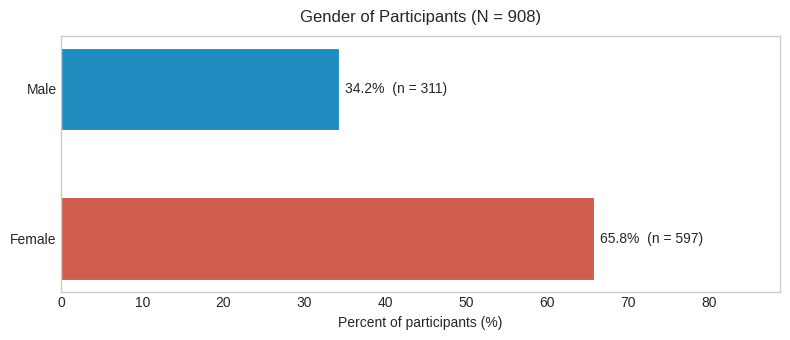

In [66]:
# Sex proportions plot (horizontal barplot for better label readability)
# Best practices: https://python-graph-gallery.com/barplot/
plot_order = [c for c in ["Missing/Other", "Male", "Female"] if c in sex_table.index]
vals = sex_table.loc[plot_order, "percent"]
cnts = sex_table.loc[plot_order, "count"]

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = [SEX_COLOR_MAP[c] for c in plot_order]

bars = ax.barh(plot_order, vals.values, color=colors, edgecolor="white",
               linewidth=0.8, height=0.55)

for bar, pct, cnt in zip(bars, vals.values, cnts.values):
    ax.text(pct + 0.8, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%  (n = {cnt})",
            ha="left", va="center", fontsize=10)

ax.set_xlim(0, vals.max() * 1.35)
ax.set_xlabel("Percent of participants (%)")
ax.set_title("Gender of Participants (N = 908)", fontsize=12, pad=10)
ax.invert_yaxis()
ax.grid(False)

plt.tight_layout()
plt.show()

In [67]:
# Humanities vs non-humanities proportions
hum_clean = demo["humanities_or_not"].astype(str).str.strip().replace({"": np.nan, "nan": np.nan})
hum_label = hum_clean.map({"+": "Humanities: Yes", "-": "Humanities: No"}).fillna("Missing/Other")

hum_counts = hum_label.value_counts(dropna=False)
hum_pct = (hum_counts / len(hum_label) * 100).round(2)
hum_table = pd.DataFrame({"count": hum_counts, "percent": hum_pct})

print("Humanities background distribution")
display(hum_table)

Humanities background distribution


,count,percent
humanities_or_not,,
Humanities: No,599,65.97
Humanities: Yes,201,22.14
Missing/Other,108,11.89


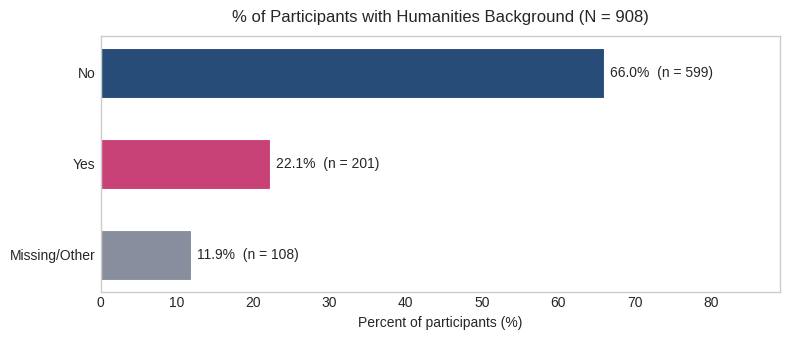

In [68]:
# Humanities proportions plot (horizontal barplot for better label readability)
# Best practices: https://python-graph-gallery.com/barplot/
raw_order = [c for c in ["Humanities: No", "Humanities: Yes", "Missing/Other"] if c in hum_table.index]
display_map = {
    "Humanities: No": "No",
    "Humanities: Yes": "Yes",
    "Missing/Other": "Missing/Other",
}
plot_labels = [display_map[c] for c in raw_order]
vals = hum_table.loc[raw_order, "percent"]
cnts = hum_table.loc[raw_order, "count"]

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = [HUM_COLOR_MAP[c] for c in raw_order]

bars = ax.barh(plot_labels, vals.values, color=colors, edgecolor="white",
               linewidth=0.8, height=0.55)

for bar, pct, cnt in zip(bars, vals.values, cnts.values):
    ax.text(pct + 0.8, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%  (n = {cnt})",
            ha="left", va="center", fontsize=10)

ax.set_xlim(0, vals.max() * 1.35)
ax.set_xlabel("Percent of participants (%)")
ax.set_title("% of Participants with Humanities Background (N = 908)", fontsize=12, pad=10)
ax.invert_yaxis()
ax.grid(False)

plt.tight_layout()
plt.show()

In [69]:
# Education/profession uniformity audit before percentages
edu_raw = demo["education_and_profession"].astype(str).str.strip()
edu_raw = edu_raw.replace({"": np.nan, "nan": np.nan})

raw_counts = edu_raw.value_counts(dropna=False)
raw_table = raw_counts.rename_axis("raw_category").reset_index(name="count")
raw_table["percent"] = (raw_table["count"] / len(edu_raw) * 100).round(2)

print("Raw education/profession categories")
print(f"- Unique raw non-missing categories: {edu_raw.dropna().nunique()}")
display(raw_table)


CANONICAL = [
    "Science and Education",
    "Service Industry",
    "IT and Engineering",
    "Art and Culture",
    "Student/School",
]
_CANONICAL_LOWER = [c.lower() for c in CANONICAL]

_MERGE = {
    "student": "Student/School",
    "school": "Student/School",
    "pensionary": "Missing/Unknown",
}


def normalize_edu(s):
    if pd.isna(s):
        return "Missing/Unknown"
    t = str(s).strip().lower().replace("&", " and ")
    t = " ".join(t.split())

    if t in _MERGE:
        return _MERGE[t]

    if t in _CANONICAL_LOWER:
        return CANONICAL[_CANONICAL_LOWER.index(t)]

    best_score, best_match = 0.0, None
    for canon, canon_low in zip(CANONICAL, _CANONICAL_LOWER):
        score = SequenceMatcher(None, t, canon_low).ratio()
        if score > best_score:
            best_score = score
            best_match = canon

    if best_score >= 0.75:
        return best_match
    return f"UNMATCHED: {t}"


edu_norm = edu_raw.map(normalize_edu)

norm_counts = edu_norm.value_counts(dropna=False)
norm_table = norm_counts.rename_axis("normalized_category").reset_index(name="count")
norm_table["percent"] = (norm_table["count"] / len(edu_norm) * 100).round(2)

print(f"\nNormalized education/profession categories ({edu_norm.nunique()} unique)")
display(norm_table)

unmatched = norm_table[norm_table["normalized_category"].str.startswith("UNMATCHED")]
if not unmatched.empty:
    print("\nUnmatched entries — review manually:")
    display(unmatched)

Raw education/profession categories
- Unique raw non-missing categories: 40


,raw_category,count,percent
0,science and education,256,28.19
1,service industry,232,25.55
2,NaN,130,14.32
3,IT and engineering,124,13.66
4,art and culture,62,6.83
5,student,18,1.98
6,Art and culture,11,1.21
7,servise industry,10,1.10
8,school,8,0.88
9,sciense and education,5,0.55



Normalized education/profession categories (6 unique)


,normalized_category,count,percent
0,Science and Education,276,30.40
1,Service Industry,258,28.41
2,IT and Engineering,143,15.75
3,Missing/Unknown,131,14.43
4,Art and Culture,74,8.15
5,Student/School,26,2.86


In [70]:
# Verification: full raw → canonical mapping with similarity scores
raw_unique = sorted(edu_raw.dropna().unique())
mapping_rows = []
for raw_val in raw_unique:
    t = raw_val.strip().lower().replace("&", " and ")
    t = " ".join(t.split())

    if t in _MERGE:
        mapped = _MERGE[t]
        best_score = 1.0
    else:
        best_score, best_match = 0.0, None
        for canon, canon_low in zip(CANONICAL, _CANONICAL_LOWER):
            score = SequenceMatcher(None, t, canon_low).ratio()
            if score > best_score:
                best_score = score
                best_match = canon
        mapped = best_match if best_score >= 0.75 else f"UNMATCHED: {t}"

    n = int(edu_raw[edu_raw == raw_val].count())
    mapping_rows.append((raw_val, mapped, round(best_score, 3), n))

mapping_df = pd.DataFrame(
    mapping_rows, columns=["raw_value", "mapped_to", "similarity", "n"]
).sort_values(["mapped_to", "similarity"], ascending=[True, True])

print(f"Raw → canonical mapping ({len(mapping_df)} raw values → "
      f"{mapping_df['mapped_to'].nunique()} categories)")
display(mapping_df.reset_index(drop=True))

Raw → canonical mapping (40 raw values → 6 categories)


,raw_value,mapped_to,similarity,n
0,art ad culture,Art and Culture,0.966,1
1,Art and culture,Art and Culture,1.000,11
2,art and culture,Art and Culture,1.000,62
3,science and engineering,IT and Engineering,0.829,2
4,IT and ingeenering,IT and Engineering,0.833,1
5,IT and engeenering,IT and Engineering,0.889,2
6,IT ahd engineering,IT and Engineering,0.944,2
7,IT and endineering,IT and Engineering,0.944,1
8,IT and engineerind,IT and Engineering,0.944,1
9,IT and ingineering,IT and Engineering,0.944,5


In [71]:
# Final categories for plotting with consistent label casing
edu_plot_df = norm_table.copy()

label_order = [
    "Science and Education",
    "Service Industry",
    "IT and Engineering",
    "Art and Culture",
    "Student/School",
    "Missing/Unknown",
]

edu_plot_df["plot_label"] = edu_plot_df["normalized_category"]
edu_plot_df["plot_label"] = pd.Categorical(
    edu_plot_df["plot_label"], categories=label_order, ordered=True
)

# Keep stable display order across notebook outputs
edu_plot_df = edu_plot_df.sort_values("plot_label").reset_index(drop=True)

N_total = len(edu_norm)
print(f"Final categories for plotting (N = {N_total})")
display(edu_plot_df[["plot_label", "count", "percent"]])

Final categories for plotting (N = 908)


,plot_label,count,percent
0,Science and Education,276,30.40
1,Service Industry,258,28.41
2,IT and Engineering,143,15.75
3,Art and Culture,74,8.15
4,Student/School,26,2.86
5,Missing/Unknown,131,14.43


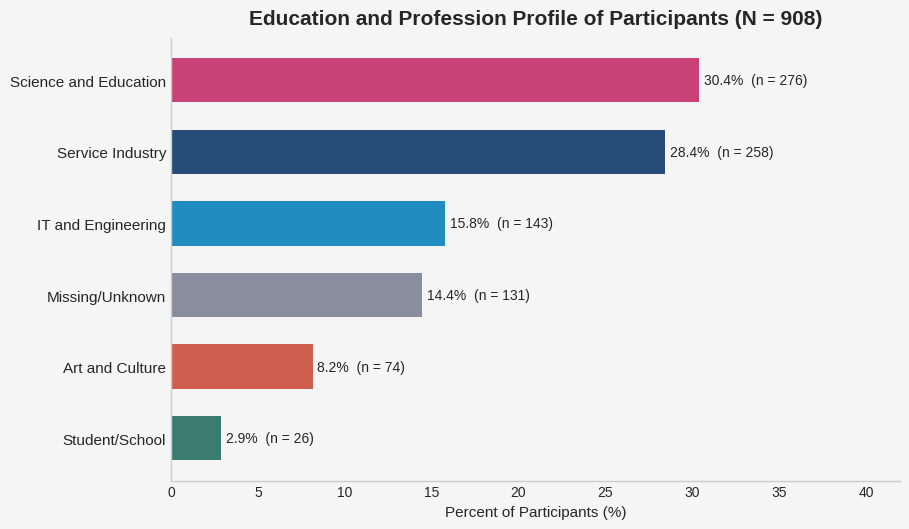

In [72]:
# Education/profession horizontal bar chart with pinned category colors
fig, ax = plt.subplots(figsize=(9.2, 5.4))
ax.set_facecolor("whitesmoke")
fig.set_facecolor("whitesmoke")

# Plot from biggest to smallest participant count
plot_df = edu_plot_df.sort_values("count", ascending=False).reset_index(drop=True)
bar_colors = [CATEGORY_COLOR_MAP[label] for label in plot_df["plot_label"].astype(str)]

bars = ax.barh(
    plot_df["plot_label"].astype(str),
    plot_df["percent"],
    color=bar_colors,
    zorder=2,
    height=0.62,
)

for bar, pct, cnt in zip(bars, plot_df["percent"], plot_df["count"]):
    ax.text(
        pct + 0.28,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  (n = {cnt})",
        ha="left",
        va="center",
        fontsize=10,
    )

ax.set_xlim(0, edu_plot_df["percent"].max() * 1.38)
ax.grid(False)
ax.invert_yaxis()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.xaxis.tick_bottom()
ax.set_xlabel("Percent of Participants (%)", fontsize=11)
ax.set_ylabel("")

ax.set_title("Education and Profession Profile of Participants (N = 908)", fontsize=15, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

In [73]:
# Age profile for merged Student/School category
demo["edu_normalized"] = edu_norm.values
age_num = pd.to_numeric(demo["age"], errors="coerce")

mask = demo["edu_normalized"] == "Student/School"
ages = age_num[mask].dropna()
print(f"Student/School (n = {mask.sum()}):")
print(f"  Age range: {ages.min():.0f}–{ages.max():.0f}")
print(f"  Mean: {ages.mean():.1f}, Median: {ages.median():.0f}, SD: {ages.std():.1f}")
print(f"  Values: {sorted(ages.values.tolist())}")
print(f"\nNote: 'Pensionary' (n=1, age 62) merged into Missing/Unknown.")

Student/School (n = 26):
  Age range: 18–29
  Mean: 20.0, Median: 19, SD: 2.9
  Values: [18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 19.0, 19.0, 19.0, 19.0, 20.0, 20.0, 20.0, 20.0, 21.0, 23.0, 24.0, 25.0, 25.0, 29.0]

Note: 'Pensionary' (n=1, age 62) merged into Missing/Unknown.


In [74]:
# Save full-width CSV with normalized education/profession categories
# Keep the same wide structure as step01 (all item columns + marker codes),
# but for adults-only rows and with normalized education labels.
normalized_out_dir = (
    PROJECT_ROOT
    / "data"
    / "stepwise_cleaned_versions"
    / "03_participant_demographics_normalized_categories"
)
normalized_out_dir.mkdir(parents=True, exist_ok=True)

normalized_participant_path = (
    normalized_out_dir
    / "ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv"
)
normalized_summary_path = (
    normalized_out_dir
    / "ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories_summary.csv"
)

# Reconstruct full-width adults-only table from raw/responses used upstream.
# - Row 0: labels
# - Row 1: codes (cla/mod/fill/etc.)
# - Rows 2+: participant responses
header_rows = raw.iloc[:2, :].copy()
responses_adults_full = responses.loc[age_adult_mask.values, :].copy().reset_index(drop=True)
responses_adults_full.iloc[:, col_edu] = edu_norm.values

out_full = pd.concat([header_rows, responses_adults_full], ignore_index=True)
out_full.to_csv(normalized_participant_path, index=False, header=False)

edu_plot_df[["plot_label", "count", "percent"]].to_csv(normalized_summary_path, index=False)

print("Saved normalized demographics outputs")
print(f"- Participant-level CSV (full width): {normalized_participant_path}")
print(f"- Category summary CSV: {normalized_summary_path}")
print(f"- Adult participant rows saved: {len(responses_adults_full)}")

Saved normalized demographics outputs
- Participant-level CSV (full width): /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv
- Category summary CSV: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories_summary.csv
- Adult participant rows saved: 908


In [ ]:
# Export publication-ready demographics package (main text + appendix)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

PROJECT_ROOT = Path("..").resolve().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "stepwise_cleaned_versions"
    / "01_participant_level_checks"
    / "participant_level_checks__step01_drop_items_and_flagged_participants"
    / "ART_pretest_(for Castano)_EN__participant_level_checks_step01.csv"
)
EXPORT_DIR = PROJECT_ROOT / "results" / "participant_demographics_eda_article_package_2026-04-06"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Color maps used for exported figures
AGE_COLOR_MAP = {
    "bars": "#6AA84F",
    "mean": "#3C78D8",
    "median": "#E69138",
    "sd1": "#6FA8DC",
    "sd2": "#B7D7A8",
}
SEX_COLOR_MAP = {"Male": "#6FA8DC", "Female": "#E69138", "Missing/Other": "#B4A7D6"}
HUM_COLOR_MAP = {
    "Humanities: Yes": "#8E7CC3",
    "Humanities: No": "#6AA84F",
    "Missing/Other": "#B4A7D6",
}
CATEGORY_COLOR_MAP = {
    "Science and Education": "#6AA84F",
    "Service Industry": "#3D85C6",
    "IT and Engineering": "#E69138",
    "Art and Culture": "#8E7CC3",
    "Student/School": "#CC0000",
    "Missing/Unknown": "#B7B7B7",
}

raw = pd.read_csv(DATA_PATH, header=None)
labels = raw.iloc[0].fillna("").astype(str).tolist()
responses = raw.iloc[2:, :].reset_index(drop=True)

def norm_label(s: str) -> str:
    return " ".join(str(s).strip().lower().split())

label_to_idx = {norm_label(lbl): idx for idx, lbl in enumerate(labels)}

def find_col(possible_names):
    for name in possible_names:
        key = norm_label(name)
        if key in label_to_idx:
            return label_to_idx[key]
    return None

col_submitted = find_col(["submitted", "submited"])
col_age = find_col(["age"])
col_sex = find_col(["sex", "sex "])
col_hum = find_col(["humanities or not"])
col_edu = find_col(["education and profession"])

required = {
    "submitted": col_submitted,
    "age": col_age,
    "sex": col_sex,
    "humanities_or_not": col_hum,
    "education_and_profession": col_edu,
}
missing_cols = [k for k, v in required.items() if v is None]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

demo = pd.DataFrame(
    {
        "submitted": responses.iloc[:, col_submitted],
        "age": responses.iloc[:, col_age],
        "sex": responses.iloc[:, col_sex],
        "humanities_or_not": responses.iloc[:, col_hum],
        "education_and_profession": responses.iloc[:, col_edu],
    }
).copy()

# Submitted date summary
submitted_dt = pd.to_datetime(demo["submitted"], errors="coerce")
submitted_date = submitted_dt.dt.date
date_range_summary = pd.DataFrame(
    {
        "metric": ["start_date", "end_date", "missing_unparseable_submitted_timestamps"],
        "value": [submitted_date.min(), submitted_date.max(), int(submitted_dt.isna().sum())],
    }
)

# Age quality split
age_num = pd.to_numeric(demo["age"], errors="coerce")
age_valid_mask = (age_num >= 10) & (age_num <= 100)
age_invalid_numeric_mask = age_num.notna() & ~age_valid_mask
age_under_18_mask = age_valid_mask & (age_num < 18)
age_adult_mask = age_valid_mask & (age_num >= 18)

age_valid = age_num[age_valid_mask]
age_under_18 = age_num[age_under_18_mask]
adult_age = age_num[age_adult_mask].dropna()

under18_breakdown = age_under_18.value_counts().sort_index()
age_quality_summary = pd.DataFrame(
    [
        {"metric": "total_participants_raw_step01", "value": int(len(demo))},
        {"metric": "valid_ages_10_to_100", "value": int(age_valid.shape[0])},
        {"metric": "missing_ages", "value": int(age_num.isna().sum())},
        {
            "metric": "invalid_numeric_ages_outside_10_100",
            "value": int(age_invalid_numeric_mask.sum()),
        },
        {"metric": "participants_under_18_with_valid_age", "value": int(age_under_18.shape[0])},
        {
            "metric": "under18_age_breakdown",
            "value": "; ".join([f"age {int(a)}: n={int(c)}" for a, c in under18_breakdown.items()])
            if not under18_breakdown.empty
            else "",
        },
        {"metric": "adult_18plus_included_for_demographics", "value": int(adult_age.shape[0])},
    ]
)

adult_age_descriptives = adult_age.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame(name="value")
adult_age_descriptives.index.name = "statistic"

# Rebind to adults for downstream demographic distributions
responses_adults = responses.loc[age_adult_mask.values, :].copy().reset_index(drop=True)
demo_adults = demo.loc[age_adult_mask].copy().reset_index(drop=True)

# Sex distribution
sex_clean = demo_adults["sex"].astype(str).str.strip().str.upper().replace({"": np.nan, "NAN": np.nan})
sex_label = sex_clean.map({"M": "Male", "F": "Female"}).fillna("Missing/Other")
sex_counts = sex_label.value_counts(dropna=False)
sex_pct = (sex_counts / len(sex_label) * 100).round(2)
sex_table = pd.DataFrame({"category": sex_counts.index, "count": sex_counts.values, "percent": sex_pct.values})

# Humanities distribution
hum_clean = demo_adults["humanities_or_not"].astype(str).str.strip().replace({"": np.nan, "nan": np.nan})
hum_label = hum_clean.map({"+": "Humanities: Yes", "-": "Humanities: No"}).fillna("Missing/Other")
hum_counts = hum_label.value_counts(dropna=False)
hum_pct = (hum_counts / len(hum_label) * 100).round(2)
hum_table = pd.DataFrame({"category": hum_counts.index, "count": hum_counts.values, "percent": hum_pct.values})

# Education normalization + audit mapping
edu_raw = demo_adults["education_and_profession"].astype(str).str.strip().replace({"": np.nan, "nan": np.nan})
raw_counts = edu_raw.value_counts(dropna=False)
raw_table = raw_counts.rename_axis("raw_category").reset_index(name="count")
raw_table["percent"] = (raw_table["count"] / len(edu_raw) * 100).round(2)

CANONICAL = [
    "Science and Education",
    "Service Industry",
    "IT and Engineering",
    "Art and Culture",
    "Student/School",
]
_CANONICAL_LOWER = [c.lower() for c in CANONICAL]
_MERGE = {
    "student": "Student/School",
    "school": "Student/School",
    "pensionary": "Missing/Unknown",
}

def normalize_edu(s):
    if pd.isna(s):
        return "Missing/Unknown"
    t = str(s).strip().lower().replace("&", " and ")
    t = " ".join(t.split())
    if t in _MERGE:
        return _MERGE[t]
    if t in _CANONICAL_LOWER:
        return CANONICAL[_CANONICAL_LOWER.index(t)]
    best_score, best_match = 0.0, None
    for canon, canon_low in zip(CANONICAL, _CANONICAL_LOWER):
        score = SequenceMatcher(None, t, canon_low).ratio()
        if score > best_score:
            best_score = score
            best_match = canon
    if best_score >= 0.75:
        return best_match
    return f"UNMATCHED: {t}"

edu_norm = edu_raw.map(normalize_edu)
norm_counts = edu_norm.value_counts(dropna=False)
norm_table = norm_counts.rename_axis("normalized_category").reset_index(name="count")
norm_table["percent"] = (norm_table["count"] / len(edu_norm) * 100).round(2)

raw_order = edu_raw.value_counts(dropna=False)
lookup = {k: v for k, v in zip(raw_order.index.tolist(), raw_order.values.tolist())}
rows = []
for raw_val in sorted(lookup.keys(), key=lambda x: str(x).lower()):
    if pd.isna(raw_val):
        raw_key = "MISSING"
        mapped = "Missing/Unknown"
        similarity = 1.0
    else:
        t = str(raw_val).strip()
        mapped = normalize_edu(raw_val)
        if mapped in CANONICAL:
            similarity = SequenceMatcher(None, t.lower().replace("&", " and "), mapped.lower()).ratio()
        elif mapped == "Missing/Unknown":
            similarity = 1.0
        else:
            similarity = 0.0
        raw_key = t
    rows.append({"raw_value": raw_key, "mapped_to": mapped, "similarity": round(float(similarity), 3), "n": int(lookup[raw_val])})
mapping_df = pd.DataFrame(rows)

# Student/School age profile
demo_adults = demo_adults.copy()
demo_adults["edu_normalized"] = edu_norm.values
student_mask = demo_adults["edu_normalized"] == "Student/School"
student_ages = pd.to_numeric(demo_adults.loc[student_mask, "age"], errors="coerce").dropna()
student_age_profile = pd.DataFrame(
    {
        "metric": ["n", "min_age", "max_age", "mean_age", "median_age", "sd_age", "sorted_values"],
        "value": [
            int(student_mask.sum()),
            float(student_ages.min()) if not student_ages.empty else np.nan,
            float(student_ages.max()) if not student_ages.empty else np.nan,
            round(float(student_ages.mean()), 2) if not student_ages.empty else np.nan,
            float(student_ages.median()) if not student_ages.empty else np.nan,
            round(float(student_ages.std()), 2) if not student_ages.empty else np.nan,
            ", ".join([str(v) for v in sorted(student_ages.values.tolist())]) if not student_ages.empty else "",
        ],
    }
)

overview = pd.DataFrame(
    [
        {"metric": "participants_raw_after_step01", "value": int(len(demo))},
        {"metric": "participants_removed_invalid_numeric_age", "value": int(age_invalid_numeric_mask.sum())},
        {"metric": "under18_participants_valid_age", "value": int(age_under_18.shape[0])},
        {"metric": "participants_adults_for_step03_eda", "value": int(len(demo_adults))},
        {"metric": "education_raw_nonmissing_unique_categories_adults", "value": int(edu_raw.dropna().nunique())},
        {"metric": "education_normalized_unique_categories_adults", "value": int(edu_norm.nunique())},
    ]
)

# Save tables (CSV only)
date_range_summary.to_csv(EXPORT_DIR / "table_submitted_date_range_summary.csv", index=False)
age_quality_summary.to_csv(EXPORT_DIR / "table_age_quality_summary_pre_adult_filter.csv", index=False)
adult_age_descriptives.to_csv(EXPORT_DIR / "table_adults_age_distribution_descriptives.csv")
sex_table.to_csv(EXPORT_DIR / "table_adults_gender_distribution.csv", index=False)
hum_table.to_csv(EXPORT_DIR / "table_adults_humanities_distribution.csv", index=False)
raw_table.to_csv(EXPORT_DIR / "table_adults_education_raw_category_counts.csv", index=False)
norm_table.to_csv(EXPORT_DIR / "table_adults_education_normalized_category_counts.csv", index=False)
mapping_df.to_csv(EXPORT_DIR / "table_adults_education_raw_to_canonical_mapping.csv", index=False)
student_age_profile.to_csv(EXPORT_DIR / "table_adults_student_school_age_profile.csv", index=False)
overview.to_csv(EXPORT_DIR / "table_step03_demographics_overview_key_metrics.csv", index=False)

# Figure 1: Adult age histogram
fig, ax = plt.subplots(figsize=(10, 6))
mean_age = adult_age.mean()
median_age = adult_age.median()
std_age = adult_age.std()
bins_fd = np.histogram_bin_edges(adult_age, bins="fd")
hist_counts, bin_edges = np.histogram(adult_age, bins=bins_fd)
bin_width = np.diff(bin_edges).mean()
ax.bar(
    bin_edges[:-1],
    hist_counts,
    width=np.diff(bin_edges),
    align="edge",
    color=AGE_COLOR_MAP["bars"],
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    zorder=2,
)

x_curve = np.linspace(float(adult_age.min()) - 1.0, float(adult_age.max()) + 1.0, 300)
if std_age > 0:
    y_curve = (1.0 / (std_age * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_curve - mean_age) / std_age) ** 2)
    y_curve = y_curve * len(adult_age) * bin_width
    ax.plot(x_curve, y_curve, color="black", linewidth=1.8, alpha=0.85, zorder=3)

ax.axvline(mean_age, color=AGE_COLOR_MAP["mean"], linestyle="--", linewidth=2, label=f"Mean = {mean_age:.1f}", zorder=4)
ax.axvline(median_age, color=AGE_COLOR_MAP["median"], linestyle="-.", linewidth=2, label=f"Median = {median_age:.1f}", zorder=4)
for k, color in [(1, AGE_COLOR_MAP["sd1"]), (2, AGE_COLOR_MAP["sd2"])]:
    low = max(18.0, mean_age - k * std_age)
    high = mean_age + k * std_age
    ax.axvspan(low, high, color=color, alpha=0.15 if k == 1 else 0.10, zorder=1)

ax.set_xlim(left=18, right=float(adult_age.max()) + 1)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Participant count")
ax.set_title(f"Age Distribution of Adult Participants (N = {len(adult_age)})", fontsize=13, pad=10)
ax.legend(loc="upper right", frameon=False)
ax.grid(False)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "figure_adults_age_distribution_histogram.png", dpi=300, bbox_inches="tight")
fig.savefig(EXPORT_DIR / "figure_adults_age_distribution_histogram.pdf", bbox_inches="tight")
plt.close(fig)

# Figure 2: Gender distribution
order = [c for c in ["Missing/Other", "Male", "Female"] if c in sex_table["category"].tolist()]
sex_plot = sex_table.set_index("category").loc[order]
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(order, sex_plot["percent"].values, color=[SEX_COLOR_MAP[c] for c in order], edgecolor="white", linewidth=0.8, height=0.55)
for bar, pct, cnt in zip(bars, sex_plot["percent"].values, sex_plot["count"].values):
    ax.text(pct + 0.8, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%  (n = {int(cnt)})", ha="left", va="center", fontsize=10)
ax.set_xlim(0, float(sex_plot["percent"].max()) * 1.35)
ax.set_xlabel("Percent of participants (%)")
ax.set_title(f"Gender of Participants (N = {len(demo_adults)})", fontsize=12, pad=10)
ax.invert_yaxis()
ax.grid(False)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "figure_adults_gender_distribution_barh.png", dpi=300, bbox_inches="tight")
fig.savefig(EXPORT_DIR / "figure_adults_gender_distribution_barh.pdf", bbox_inches="tight")
plt.close(fig)

# Figure 3: Humanities distribution
raw_order_h = [c for c in ["Humanities: No", "Humanities: Yes", "Missing/Other"] if c in hum_table["category"].tolist()]
display_map = {"Humanities: No": "No", "Humanities: Yes": "Yes", "Missing/Other": "Missing/Other"}
hum_plot = hum_table.set_index("category").loc[raw_order_h]
plot_labels = [display_map[c] for c in raw_order_h]
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(plot_labels, hum_plot["percent"].values, color=[HUM_COLOR_MAP[c] for c in raw_order_h], edgecolor="white", linewidth=0.8, height=0.55)
for bar, pct, cnt in zip(bars, hum_plot["percent"].values, hum_plot["count"].values):
    ax.text(pct + 0.8, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}%  (n = {int(cnt)})", ha="left", va="center", fontsize=10)
ax.set_xlim(0, float(hum_plot["percent"].max()) * 1.35)
ax.set_xlabel("Percent of participants (%)")
ax.set_title(f"% of Participants with Humanities Background (N = {len(demo_adults)})", fontsize=12, pad=10)
ax.invert_yaxis()
ax.grid(False)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "figure_adults_humanities_distribution_barh.png", dpi=300, bbox_inches="tight")
fig.savefig(EXPORT_DIR / "figure_adults_humanities_distribution_barh.pdf", bbox_inches="tight")
plt.close(fig)

# Figure 4: Education/profession profile
label_order = [
    "Science and Education",
    "Service Industry",
    "IT and Engineering",
    "Art and Culture",
    "Student/School",
    "Missing/Unknown",
]
edu_plot_df = norm_table.copy()
edu_plot_df["plot_label"] = pd.Categorical(edu_plot_df["normalized_category"], categories=label_order, ordered=True)
edu_plot_df = edu_plot_df.sort_values("plot_label").reset_index(drop=True)
plot_df = edu_plot_df.sort_values("count", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.2, 5.4))
ax.set_facecolor("whitesmoke")
fig.set_facecolor("whitesmoke")
bars = ax.barh(
    plot_df["normalized_category"].astype(str),
    plot_df["percent"].values,
    color=[CATEGORY_COLOR_MAP[x] for x in plot_df["normalized_category"].astype(str)],
    zorder=2,
    height=0.62,
)
for bar, pct, cnt in zip(bars, plot_df["percent"], plot_df["count"]):
    ax.text(
        pct + 0.28,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  (n = {int(cnt)})",
        ha="left",
        va="center",
        fontsize=10,
    )
ax.set_xlim(0, float(edu_plot_df["percent"].max()) * 1.38)
ax.grid(False)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=10)
ax.xaxis.tick_bottom()
ax.set_xlabel("Percent of Participants (%)", fontsize=11)
ax.set_ylabel("")
ax.set_title(f"Education and Profession Profile of Participants (N = {len(demo_adults)})", fontsize=15, fontweight="bold", pad=10)
fig.tight_layout()
fig.savefig(EXPORT_DIR / "figure_adults_education_profession_profile_barh.png", dpi=300, bbox_inches="tight")
fig.savefig(EXPORT_DIR / "figure_adults_education_profession_profile_barh.pdf", bbox_inches="tight")
plt.close(fig)

readme = """# Participant Demographics EDA Article Package

Source notebook: `scripts/eda/03_participant_demographics_eda.ipynb`

This package contains publication-oriented artifacts from participant demographics EDA after applying the notebook's adult-only analysis frame (`age >= 18`, valid age range `10-100`) and education/profession harmonization.

## Suggested Main-Text Figures

1. `figure_adults_age_distribution_histogram.png` and `.pdf`
   - Adult age distribution with mean/median and SD bands.
2. `figure_adults_gender_distribution_barh.png` and `.pdf`
   - Gender composition of adult sample.
3. `figure_adults_humanities_distribution_barh.png` and `.pdf`
   - Humanities background composition.
4. `figure_adults_education_profession_profile_barh.png` and `.pdf`
   - Normalized education/profession profile.

## Suggested Main-Text Tables

1. `table_step03_demographics_overview_key_metrics.csv`
   - Compact metrics for sample filtering and final adult N.
2. `table_adults_age_distribution_descriptives.csv`
   - Adult age descriptive statistics.
3. `table_adults_gender_distribution.csv`
   - Adult gender counts and percentages.
4. `table_adults_humanities_distribution.csv`
   - Adult humanities counts and percentages.
5. `table_adults_education_normalized_category_counts.csv`
   - Final normalized education/profession categories.

## Suggested Appendix / Reproducibility Tables

1. `table_submitted_date_range_summary.csv`
   - Collection date range and parse quality checks.
2. `table_age_quality_summary_pre_adult_filter.csv`
   - Pre-step03 age screening details and under-18 breakdown.
3. `table_adults_education_raw_category_counts.csv`
   - Raw education/profession string frequencies.
4. `table_adults_education_raw_to_canonical_mapping.csv`
   - Raw-to-canonical mapping with similarity score and frequency.
5. `table_adults_student_school_age_profile.csv`
   - Age profile of merged `Student/School` group.

## Notes

- Tables are CSV-only by request.
- Plots are exported as both PNG and PDF by request.
- This folder is intended for manuscript production and reproducibility documentation.
"""
(EXPORT_DIR / "README.md").write_text(readme, encoding="utf-8")

print(f"Saved demographics article package to: {EXPORT_DIR}")
print("Done: CSV tables, PNG+PDF figures, and README manifest.")

### Notes

- Category harmonization uses fuzzy matching (`SequenceMatcher`, threshold ≥ 0.75) against 7 canonical labels + Missing/Unknown.
- The full raw → canonical mapping with similarity scores is printed above for audit.
- Any raw value that falls below the 0.75 threshold is flagged as `UNMATCHED` for manual review.